In [1]:

from pathlib import Path
import pandas as pd
import numpy as np

ARC_QC   = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/preprocess_qc.csv")
ATLAS_QC = Path("/home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/preprocess_qc.csv")

arc   = pd.read_csv(ARC_QC)
atlas = pd.read_csv(ATLAS_QC)

def q(a, p): return float(np.percentile(a, p)) if len(a) else np.nan

def summarize(df, label):
    out = {}
    out["Dataset"] = label
    out["N"] = len(df)
    # lesion volume (raw + clean)
    lv  = df["mask_ml"].values
    lvc = df["mask_ml_clean"].values
    out["Lesion mL (min/med/max)"] = f"{lv.min():.2f}/{q(lv,50):.2f}/{lv.max():.2f}"
    out["Lesion mL clean (min/med/max)"] = f"{lvc.min():.2f}/{q(lvc,50):.2f}/{lvc.max():.2f}"
    out["% changed by clean"] = f"{100.0 * (df['mask_voxels']!=df['mask_voxels_clean']).mean():.1f}%"
    # brain fraction (raw)
    bf = df["brain_frac"].values
    out["Brain frac (mean±sd)"] = f"{bf.mean():.3f}±{bf.std():.3f}"
    out["Brain frac p10/50/90"] = f"{q(bf,10):.3f}/{q(bf,50):.3f}/{q(bf,90):.3f}"
    # image geometry (should be uniform after MNI, but we show min/median/max to be explicit)
    vx = df["voxel_mm3"].values
    out["Voxel mm³ (unique)"] = ", ".join(sorted({f"{v:.3f}" for v in vx}))
    shapes = df[["t1_shape_x","t1_shape_y","t1_shape_z"]].dropna().astype(int)
    sx, sy, sz = shapes["t1_shape_x"].values, shapes["t1_shape_y"].values, shapes["t1_shape_z"].values
    out["Shape (min/med/max)"] = f"{sx.min()}×{sy.min()}×{sz.min()} / {int(q(sx,50))}×{int(q(sy,50))}×{int(q(sz,50))} / {sx.max()}×{sy.max()}×{sz.max()}"
    return out

rows = [summarize(arc, "ARC"), summarize(atlas, "ATLAS")]
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))


Dataset   N Lesion mL (min/med/max) Lesion mL clean (min/med/max) % changed by clean Brain frac (mean±sd) Brain frac p10/50/90 Voxel mm³ (unique)                     Shape (min/med/max)
    ARC 203       0.00/50.77/211.75             0.00/50.77/211.75               0.5%          0.242±0.005    0.238/0.241/0.248              1.000 193×229×193 / 193×229×193 / 193×229×193
  ATLAS 655        0.00/3.31/163.42              0.00/3.31/163.42               9.8%          0.549±0.079    0.496/0.529/0.608              1.000 193×229×193 / 193×229×193 / 193×229×193


In [6]:
# ==== Resolution/shape ranges (ARC native T1w vs ATLAS Training T1w) ====
from pathlib import Path
import nibabel as nib
import numpy as np
from math import prod

# ---- Paths ----
ARC_ROOT      = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks")
ATLAS_IMG_DIR = Path("/home/rbielski/Atlas_2/Training/Images")

# ---- Helpers ----
def is_native_arc_t1(p: Path) -> bool:
    n = p.name
    return (
        n.endswith(".nii.gz")
        and "_T1w" in n
        and all(s not in n for s in ["_MNI", "_standardized", "_lesion_mask", "mask", "masks_clean", "t1_norm"])
    )

def is_atlas_t1(p: Path) -> bool:
    n = p.name
    return n.endswith(".nii.gz") and "_T1w" in n and "mask" not in n.lower()

def stats_for(imgs: list[Path], label: str):
    if not imgs:
        print(f"\n=== {label} ===\n(no files)")
        return
    shapes = []
    zooms  = []
    voxvol = []
    fovml  = []
    for p in imgs:
        img = nib.load(str(p))
        shp = img.shape[:3]
        z = tuple(float(v) for v in img.header.get_zooms()[:3])
        shapes.append(shp)
        zooms.append(z)
        vmm3 = z[0]*z[1]*z[2]
        voxvol.append(vmm3)
        fovml.append(prod(shp)*vmm3/1000.0)
    shapes = np.array(shapes, dtype=float)
    zooms  = np.array(zooms, dtype=float)
    voxvol = np.array(voxvol, dtype=float)
    fovml  = np.array(fovml, dtype=float)

    def pct(a,q): return float(np.percentile(a,q))

    # unique voxel spacings (rounded for readability)
    uniq = sorted({f"{z[0]:.3f}×{z[1]:.3f}×{z[2]:.3f}" for z in zooms})

    print(f"\n=== {label} ===")
    print(f"Files: {len(imgs)}")
    print("Voxel spacing (mm) unique:", ", ".join(uniq))
    # Per-axis ranges
    for i,ax in enumerate("xyz"):
        arr = zooms[:,i]
        print(f"  spacing {ax} (mm) min/med/max: {arr.min():.3f} / {pct(arr,50):.3f} / {arr.max():.3f}")
    print(f"Voxel volume (mm³) min/med/max: {voxvol.min():.3f} / {pct(voxvol,50):.3f} / {voxvol.max():.3f}")

    # Shapes
    sx, sy, sz = shapes[:,0], shapes[:,1], shapes[:,2]
    print(f"Shape (x×y×z) min: {int(sx.min())}×{int(sy.min())}×{int(sz.min())}")
    print(f"Shape (x×y×z) med: {int(pct(sx,50))}×{int(pct(sy,50))}×{int(pct(sz,50))}")
    print(f"Shape (x×y×z) max: {int(sx.max())}×{int(sy.max())}×{int(sz.max())}")
    print(f"FOV volume (mL)   min/med/max: {fovml.min():.1f} / {pct(fovml,50):.1f} / {fovml.max():.1f}")

# ---- Collect & report ----
arc_imgs   = [p for p in ARC_ROOT.glob("*_T1w.nii.gz") if is_native_arc_t1(p)]
atlas_imgs = sorted([p for p in ATLAS_IMG_DIR.glob("*.nii.gz") if is_atlas_t1(p)])

stats_for(arc_imgs,   "ARC (native T1w)")
stats_for(atlas_imgs, "ATLAS Training (T1w, as provided)")



=== ARC (native T1w) ===
Files: 203
Voxel spacing (mm) unique: 1.000×1.000×1.000
  spacing x (mm) min/med/max: 1.000 / 1.000 / 1.000
  spacing y (mm) min/med/max: 1.000 / 1.000 / 1.000
  spacing z (mm) min/med/max: 1.000 / 1.000 / 1.000
Voxel volume (mm³) min/med/max: 1.000 / 1.000 / 1.000
Shape (x×y×z) min: 160×240×256
Shape (x×y×z) med: 192×256×256
Shape (x×y×z) max: 192×256×256
FOV volume (mL)   min/med/max: 10485.8 / 12582.9 / 12582.9

=== ATLAS Training (T1w, as provided) ===
Files: 655
Voxel spacing (mm) unique: 1.000×1.000×1.000
  spacing x (mm) min/med/max: 1.000 / 1.000 / 1.000
  spacing y (mm) min/med/max: 1.000 / 1.000 / 1.000
  spacing z (mm) min/med/max: 1.000 / 1.000 / 1.000
Voxel volume (mm³) min/med/max: 1.000 / 1.000 / 1.000
Shape (x×y×z) min: 197×233×189
Shape (x×y×z) med: 197×233×189
Shape (x×y×z) max: 197×233×189
FOV volume (mL)   min/med/max: 8675.3 / 8675.3 / 8675.3


In [7]:
# ==== Effective resolution in MNI: FWHM (mm), high-frequency energy, Laplacian variance ====
from pathlib import Path
import numpy as np, nibabel as nib, pandas as pd
from math import prod
from numpy.fft import fftn, fftshift
from scipy.ndimage import gaussian_filter, laplace

# ---- Set your standardized MNI T1 paths (already normalized to 193x229x193, 1mm) ----
ARC_T1_DIR   = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/t1_norm")
ATLAS_T1_DIR = Path("/home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/t1_norm")

assert ARC_T1_DIR.exists(), f"Missing {ARC_T1_DIR}"
assert ATLAS_T1_DIR.exists(), f"Missing {ATLAS_T1_DIR}"

def zscore_in_brain(vol):
    m = vol != 0
    if not m.any():
        return vol.astype(np.float32), m
    v = vol[m].astype(np.float32)
    mu, sd = v.mean(), v.std() if v.std() > 0 else 1.0
    out = np.zeros_like(vol, dtype=np.float32)
    out[m] = (vol[m] - mu) / sd
    return out, m

def estimate_fwhm_gaussian_acf(img, mask, max_shift=3):
    """
    Estimate whole-brain Gaussian smoothness (FWHM) by fitting a Gaussian
    to the spatial autocorrelation near the origin (small voxel shifts).
    Returns a single isotropic FWHM in mm (assumes 1 mm voxels).
    """
    # use small integer shifts and average correlations across axes/directions
    shifts = [1, 2, 3]
    cors = []
    base = img[mask]
    base -= base.mean()
    base_var = (base**2).mean() + 1e-8
    for s in shifts:
        for axis in range(3):
            # shift img by +s and -s along axis inside the mask bounds
            slicer_f = [slice(None)]*3
            slicer_g = [slice(None)]*3
            if axis == 0:
                slicer_f[0] = slice(0, -s)
                slicer_g[0] = slice(s, None)
            elif axis == 1:
                slicer_f[1] = slice(0, -s)
                slicer_g[1] = slice(s, None)
            else:
                slicer_f[2] = slice(0, -s)
                slicer_g[2] = slice(s, None)

            f = img[tuple(slicer_f)]
            g = img[tuple(slicer_g)]
            m = mask[tuple(slicer_f)] & mask[tuple(slicer_g)]
            if m.sum() < 1000:
                continue
            fv = f[m] - f[m].mean()
            gv = g[m] - g[m].mean()
            denom = (fv.std() * gv.std()) + 1e-8
            cors.append((s, (fv*gv).mean() / denom))
    if not cors:
        return np.nan
    # Fit R(s) ≈ exp(-(s^2)/(2*sigma^2)); FWHM = 2.355*sigma
    # Take log: ln R = -(s^2)/(2*sigma^2) ⇒ slope vs s^2
    ss = np.array([c[0] for c in cors], dtype=float)
    rr = np.array([max(min(c[1], 0.999), 1e-6) for c in cors], dtype=float)  # clamp
    # group by shift distance (average across axes)
    f_df = {}
    for s, r in zip(ss, rr):
        f_df.setdefault(s, []).append(r)
    s2 = np.array(sorted(f_df.keys()), dtype=float)**2
    R  = np.array([np.mean(f_df[s]) for s in sorted(f_df.keys())])
    lnR = np.log(R)
    # linear fit: lnR = a + b * s^2  with expected a≈0; b = -1/(2*sigma^2)
    A = np.vstack([np.ones_like(s2), s2]).T
    a, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
    if b >= 0:  # non-sensical (no decay)
        return np.nan
    sigma_vox = np.sqrt(-1.0 / (2.0*b))
    fwhm_mm = 2.355 * sigma_vox  # 1 mm voxels
    return float(fwhm_mm)

def high_freq_energy_ratio(img, mask, cutoff=0.25):
    """
    Fraction of power above a normalized radial frequency cutoff (0..0.5 Nyquist).
    Higher ⇒ more high-frequency content (sharper).
    """
    # pad to next power-of-two for nicer FFT (optional)
    vol = np.zeros_like(img, dtype=np.float32)
    vol[mask] = img[mask]
    F = fftshift(fftn(vol))
    P = (np.abs(F)**2).astype(np.float64)
    # radial mask
    nx, ny, nz = img.shape
    cx, cy, cz = (np.array(img.shape)-1)/2.0
    x = np.arange(nx) - cx
    y = np.arange(ny) - cy
    z = np.arange(nz) - cz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    # normalized radius: 0 at DC, 0.5 at Nyquist for each axis → approximate isotropic radius
    rx = np.abs(X) / (nx/2.0)
    ry = np.abs(Y) / (ny/2.0)
    rz = np.abs(Z) / (nz/2.0)
    r = np.sqrt((rx**2 + ry**2 + rz**2)/3.0)
    hf = P[r >= cutoff].sum()
    tot= P.sum() + 1e-12
    return float(hf / tot)

def laplacian_variance(img, mask):
    # On z-scored image; larger ⇒ sharper
    L = laplace(img)
    return float(L[mask].var())

def scan_dir(dir_path: Path, label: str):
    rows = []
    files = sorted(dir_path.glob("*.nii*"))
    for p in files:
        try:
            img = nib.load(str(p)).get_fdata().astype(np.float32)
            zimg, m = zscore_in_brain(img)
            if m.sum() < 5000:
                continue
            fwhm = estimate_fwhm_gaussian_acf(zimg, m)
            hfe  = high_freq_energy_ratio(zimg, m, cutoff=0.25)
            vol  = laplacian_variance(zimg, m)
            rows.append(dict(dataset=label, path=str(p), fwhm_mm=fwhm, hi_freq_energy=hfe, lap_var=vol))
        except Exception as e:
            rows.append(dict(dataset=label, path=str(p), fwhm_mm=np.nan, hi_freq_energy=np.nan, lap_var=np.nan))
    return pd.DataFrame(rows)

arc_df   = scan_dir(ARC_T1_DIR,   "ARC")
atlas_df = scan_dir(ATLAS_T1_DIR, "ATLAS")
df = pd.concat([arc_df, atlas_df], ignore_index=True)

def summarize(df, label):
    d = df[df["dataset"]==label]
    n = len(d)
    print(f"\n=== {label} — effective resolution proxies (MNI 1mm) ===")
    print(f"Files: {n}")
    for col, desc in [
        ("fwhm_mm", "FWHM blur (mm, smaller=sharper)"),
        ("hi_freq_energy", "High-freq energy fraction (larger=sharper)"),
        ("lap_var", "Variance of Laplacian (larger=sharper)")
    ]:
        v = d[col].dropna().to_numpy()
        if v.size == 0:
            print(f"  {desc}: (no data)")
            continue
        p10, p50, p90 = np.percentile(v, [10,50,90])
        print(f"  {desc}: p10/50/90 = {p10:.3f} / {p50:.3f} / {p90:.3f} | mean±sd = {v.mean():.3f}±{v.std():.3f}")

summarize(df, "ARC")
summarize(df, "ATLAS")

# Save per-image metrics for plotting later
out_csv = ARC_T1_DIR.parent / "_effective_resolution_metrics.csv"
df.to_csv(out_csv, index=False)
print(f"\nWrote: {out_csv}")



=== ARC — effective resolution proxies (MNI 1mm) ===
Files: 203
  FWHM blur (mm, smaller=sharper): p10/50/90 = 7.674 / 8.472 / 9.692 | mean±sd = 8.580±0.764
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.104 / 0.131 / 0.159 | mean±sd = 0.131±0.020
  Variance of Laplacian (larger=sharper): p10/50/90 = 1.912 / 2.428 / 2.882 | mean±sd = 2.419±0.374

=== ATLAS — effective resolution proxies (MNI 1mm) ===
Files: 655
  FWHM blur (mm, smaller=sharper): p10/50/90 = 6.822 / 7.851 / 9.415 | mean±sd = 8.015±1.138
  High-freq energy fraction (larger=sharper): p10/50/90 = 0.054 / 0.095 / 0.142 | mean±sd = 0.097±0.035
  Variance of Laplacian (larger=sharper): p10/50/90 = 0.831 / 1.488 / 2.141 | mean±sd = 1.498±0.526

Wrote: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_effective_resolution_metrics.csv


In [26]:
# === Recompute ONLY hires / lores (no middle), per dataset, and write combined manifests ===
import os, re, shutil
from pathlib import Path
import numpy as np, pandas as pd

# ----- Inputs -----
ARC_STD   = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized")
ATLAS_STD = Path("/home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized")

# Use the combined metrics you wrote earlier (contains both ARC + ATLAS rows).
# If you instead want to base this just on the “_normal” subset, point to:
#   ARC_STD / "_normal" / "_effective_resolution_metrics.csv" and
#   ATLAS_STD / "_normal" / "_effective_resolution_metrics.csv"
METRICS_CSV = ARC_STD / "_effective_resolution_metrics.csv"
assert METRICS_CSV.exists(), f"Missing metrics: {METRICS_CSV}"

# Tail proportion (top P → hires, bottom P → lores)
P = 0.30

def ensure_dirs(*ds):
    for d in ds: d.mkdir(parents=True, exist_ok=True)

def extract_key(path_str: str) -> str:
    n = Path(path_str).name
    m_sub = re.search(r"(sub-[A-Za-z0-9]+)", n)
    m_ses = re.search(r"(ses-[A-Za-z0-9]+)", n)
    parts = [m_sub.group(1) if m_sub else None, m_ses.group(1) if m_ses else None]
    return "_".join([x for x in parts if x])

def zscore(a):
    a = np.asarray(a, float)
    mu, sd = np.nanmean(a), np.nanstd(a)
    return (a - mu) / (sd + 1e-12)

def find_one(std_root: Path, key: str, kind: str):
    if kind == "t1":
        c = sorted((std_root/"t1_norm").glob(f"{key}*T1w*nii*"))
    else:
        c = sorted((std_root/"masks_clean").glob(f"{key}*mask*nii*"))
    return c[0] if c else None

def safe_link(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if dst.exists() or dst.is_symlink(): dst.unlink()
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def split_one_dataset(std_root: Path, all_metrics: pd.DataFrame, label: str, P=0.30):
    # Narrow to this dataset and require all three metrics
    d = all_metrics.query("dataset == @label").copy()
    d = d.dropna(subset=["fwhm_mm", "hi_freq_energy", "lap_var"])
    if d.empty:
        print(f"[{label}] No rows with complete metrics; skipping.")
        return None

    # Composite sharpness score (larger = sharper)
    d["score"] = zscore(-d["fwhm_mm"]) + zscore(d["hi_freq_energy"]) + zscore(d["lap_var"])
    d["key"]   = d["path"].apply(extract_key)

    # Keep only pairs that exist in standardized t1_norm + masks_clean
    t1_dir, msk_dir = std_root/"t1_norm", std_root/"masks_clean"
    assert t1_dir.exists() and msk_dir.exists(), f"Missing standardized dirs under {std_root}"
    d["t1_path"]  = d["key"].apply(lambda k: find_one(std_root, k, "t1"))
    d["msk_path"] = d["key"].apply(lambda k: find_one(std_root, k, "mask"))
    d = d[(d["t1_path"].notna()) & (d["msk_path"].notna())]

    if d.empty:
        print(f"[{label}] No matched T1/mask pairs; skipping.")
        return None

    # Determine hires/lores thresholds in THIS dataset
    q_lo = d["score"].quantile(P)         # bottom tail → lores
    q_hi = d["score"].quantile(1.0 - P)   # top tail   → hires

    d["split"] = np.where(d["score"] >= q_hi, "hires",
                   np.where(d["score"] <= q_lo, "lores", "middle"))

    # Materialize ONLY hires/lores folders (ignore 'middle')
    hires_t1, hires_m = std_root/"_hires"/"t1_norm",   std_root/"_hires"/"masks_clean"
    lores_t1, lores_m = std_root/"_lores"/"t1_norm",   std_root/"_lores"/"masks_clean"
    ensure_dirs(hires_t1, hires_m, lores_t1, lores_m)

    counts = {"hires": 0, "lores": 0, "middle": 0}
    for _, r in d.iterrows():
        if r["split"] == "hires":
            safe_link(Path(r["t1_path"]),  hires_t1/Path(r["t1_path"]).name)
            safe_link(Path(r["msk_path"]), hires_m /Path(r["msk_path"]).name)
            counts["hires"] += 1
        elif r["split"] == "lores":
            safe_link(Path(r["t1_path"]),  lores_t1/Path(r["t1_path"]).name)
            safe_link(Path(r["msk_path"]), lores_m /Path(r["msk_path"]).name)
            counts["lores"] += 1
        else:
            counts["middle"] += 1  # we just ignore them

    # Save per-dataset split CSV (all rows, but only hires/lores are materialized)
    out_csv = std_root / "_resolution_splits.csv"
    d[["key","path","fwhm_mm","hi_freq_energy","lap_var","score","split"]].sort_values(
        ["split","score"], ascending=[True, False]).to_csv(out_csv, index=False)

    def q(a): 
        a = a.dropna().to_numpy()
        return (np.percentile(a,10), np.percentile(a,50), np.percentile(a,90)) if a.size else (np.nan,)*3

    print(f"\n[{label}] split @ P={int(P*100)}% each tail")
    print(f"  hires: {counts['hires']} | lores: {counts['lores']} | middle (ignored): {counts['middle']}")
    print(f"  thresholds: score ≤ {q_lo:.3f} (lores), ≥ {q_hi:.3f} (hires)")
    for col, desc in [
        ("fwhm_mm","FWHM blur (mm, smaller=sharper)"),
        ("hi_freq_energy","High-freq energy (larger=sharper)"),
        ("lap_var","Laplacian variance (larger=sharper)"),
    ]:
        h10,h50,h90 = q(d.loc[d["split"]=="hires", col])
        l10,l50,l90 = q(d.loc[d["split"]=="lores", col])
        print(f"  {desc}:\n    hires p10/50/90 = {h10:.3f}/{h50:.3f}/{h90:.3f}"
              f"\n    lores p10/50/90 = {l10:.3f}/{l50:.3f}/{l90:.3f}")
    print(f"  Wrote: {out_csv}")
    print(f"  Folders:\n    hires → {std_root/'_hires'}\n    lores → {std_root/'_lores'}")
    return d

# ---- Run per dataset ----
metrics = pd.read_csv(METRICS_CSV)
arc_df = split_one_dataset(ARC_STD,   metrics, "ARC",   P)
atl_df = split_one_dataset(ATLAS_STD, metrics, "ATLAS", P)

# ---- Combined manifests (only hires & lores; no middle) ----
def rows_to_manifest(d: pd.DataFrame, bin_name: str, dataset_label: str):
    d = d[d["split"]==bin_name].copy()
    d["dataset"] = dataset_label
    return d[["key","dataset","t1_path","msk_path","score"]].rename(
        columns={"t1_path":"image_path","msk_path":"mask_path"})

man_root = ARC_STD / "_combined_manifests_2bins"
man_root.mkdir(parents=True, exist_ok=True)

if arc_df is not None and atl_df is not None:
    for bin_name in ("hires","lores"):
        m = pd.concat([rows_to_manifest(arc_df, bin_name, "ARC"),
                       rows_to_manifest(atl_df, bin_name, "ATLAS")], ignore_index=True)
        out_csv = man_root / f"combined_{bin_name}.csv"
        m.sort_values(["dataset","key"]).to_csv(out_csv, index=False)
        print(f"Wrote: {out_csv}  (n={len(m)})")



[ARC] split @ P=30% each tail
  hires: 61 | lores: 61 | middle (ignored): 81
  thresholds: score ≤ -1.283 (lores), ≥ 1.419 (hires)
  FWHM blur (mm, smaller=sharper):
    hires p10/50/90 = 7.356/7.959/8.736
    lores p10/50/90 = 8.454/9.160/10.135
  High-freq energy (larger=sharper):
    hires p10/50/90 = 0.141/0.151/0.168
    lores p10/50/90 = 0.095/0.108/0.125
  Laplacian variance (larger=sharper):
    hires p10/50/90 = 2.550/2.774/3.125
    lores p10/50/90 = 1.693/2.024/2.379
  Wrote: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_resolution_splits.csv
  Folders:
    hires → /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_hires
    lores → /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_lores

[ATLAS] split @ P=30% each tail
  hires: 197 | lores: 197 | middle (ignored): 261
  thresholds: score ≤ -1.475 (lores), ≥ 1.478 (hires)
 

scans standardized / _normal T1+mask pairs from both datasets,

recomputes a resolution/quality score per case across the entire combined pool,

puts the bottom 30% into _combined_lores/ and the remaining 70% into _combined_hires/ (with t1_norm/ and masks_clean/ subfolders),

writes a combined manifest CSV with all metrics and paths.


# Reolution determination:

We compute three content-based sharpness proxies (FWHM blur ↓, high-freq energy ↑, Laplacian-variance ↑) on each normalized MNI T1w.

We z-score each metric across all images (ARC+ATLAS together) and combine:
score = 0.5*z(HF) + 0.3*z(LapVar) + 0.2*z(−FWHM) → bigger = sharper.

We take the bottom 30% of scores globally as lores; all remaining (70%) as hires.

We then materialize two unified folders with symlinks/copies and write a manifest CSV containing all metrics + paths.

In [35]:
# === Combined (ARC+ATLAS) resolution split on standardized _normal sets ===
from pathlib import Path
import os, re, shutil
import numpy as np, pandas as pd
import nibabel as nib
from scipy.ndimage import gaussian_filter, laplace
from numpy.fft import rfftn

# ---- Inputs (post tiny-lesion filtering) ----
ARC_STD   = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_normal")
ATLAS_STD = Path("/home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/_normal")

OUT_ROOT  = ARC_STD.parent / "_combined_manifests_2bins_normal"
OUT_HI    = OUT_ROOT / "_combined_hires"
OUT_LO    = OUT_ROOT / "_combined_lores"

P_LORES   = 0.30  # bottom 30% = low-res; remaining 70% = high-res

# ---------------- helpers ----------------
def ensure_dirs(*paths):
    for p in paths:
        p.mkdir(parents=True, exist_ok=True)

def key_from_name(name: str) -> str:
    m_sub = re.search(r"(sub-[^_]+)", name)
    m_ses = re.search(r"(ses-[^_]+)", name)
    parts=[]
    if m_sub: parts.append(m_sub.group(1))
    if m_ses: parts.append(m_ses.group(1))
    return "_".join(parts)

def map_pairs(std_root: Path):
    t1_dir  = std_root / "t1_norm"
    msk_dir = std_root / "masks_clean"
    assert t1_dir.exists() and msk_dir.exists(), f"Missing {t1_dir} or {msk_dir}"
    t1_map, msk_map = {}, {}
    for p in t1_dir.glob("*T1w*nii*"):
        t1_map[key_from_name(p.name)] = p
    for p in msk_dir.glob("*mask*nii*"):
        msk_map[key_from_name(p.name)] = p
    keys = sorted(set(t1_map) & set(msk_map))
    return {k: (t1_map[k], msk_map[k]) for k in keys}

# ---------------- resolution metrics ----------------
def _crop(vol, pad=6):
    nz = np.argwhere(vol>0)
    if not nz.size: return vol
    lo = np.maximum(nz.min(0)-pad, 0); hi = np.minimum(nz.max(0)+pad+1, vol.shape)
    z0,y0,x0 = lo; z1,y1,x1 = hi
    return vol[z0:z1, y0:y1, x0:x1]

def fwhm_blur_mm(vol, vox_mm):
    v = _crop(vol)
    nz = v[v>0]
    if nz.size: v = np.clip(v/np.percentile(nz,99), 0, 1)
    sigmas = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
    F = np.abs(rfftn(v))**2; F /= F.max()+1e-12
    errs=[]
    for s in sigmas:
        Fs = np.abs(rfftn(gaussian_filter(v, s)))**2; Fs /= Fs.max()+1e-12
        errs.append(np.mean((F-Fs)**2))
    s_best = float(sigmas[int(np.argmin(errs))])
    return 2.355 * s_best * float(np.mean(vox_mm))

def high_freq_energy_frac(vol, cutoff=0.25):
    v = _crop(vol)
    nz = v[v>0]
    if nz.size: v = np.clip(v/np.percentile(nz,99), 0, 1)
    V = np.abs(np.fft.fftn(v))**2
    nz_, ny_, nx_ = v.shape
    kz = np.fft.fftfreq(nz_); ky = np.fft.fftfreq(ny_); kx = np.fft.fftfreq(nx_)
    KZ, KY, KX = np.meshgrid(kz, ky, kx, indexing="ij")
    Kr = np.sqrt(KZ**2 + KY**2 + KX**2)
    E = V.sum(); E_hi = V[Kr >= cutoff*0.5].sum()
    return float(E_hi/(E+1e-12))

def laplacian_variance(vol):
    v = _crop(vol)
    L = laplace(v)
    m = (v>0)
    return float(np.var(L[m])) if m.any() else float(np.var(L))

def compute_metrics(t1_path: Path):
    img = nib.load(str(t1_path))
    vol = img.get_fdata()
    if vol.ndim == 4 and vol.shape[-1] == 1: vol = vol[...,0]
    vox = tuple(float(x) for x in img.header.get_zooms()[:3])
    return dict(
        fwhm_mm = fwhm_blur_mm(vol, vox),
        hi_freq_energy = high_freq_energy_frac(vol),
        lap_var = laplacian_variance(vol),
    )

def zscore(x: np.ndarray):
    x = x.astype(float)
    mu, sd = np.nanmean(x), np.nanstd(x)
    if not np.isfinite(sd) or sd <= 0: return np.zeros_like(x)
    return (x - mu) / sd

# ---------------- collect, score, split ----------------
arc_pairs   = map_pairs(ARC_STD)
atlas_pairs = map_pairs(ATLAS_STD)
print(f"ARC keys: {len(arc_pairs)} | ATLAS keys: {len(atlas_pairs)}")

records = []
for ds_name, pairs in [("ARC", arc_pairs), ("ATLAS", atlas_pairs)]:
    for k, (t1, msk) in pairs.items():
        m = compute_metrics(t1)
        r = dict(dataset=ds_name, key=k, t1_path=str(t1), mask_path=str(msk))
        r.update(m)                # <-- FIX: merge metrics into the record
        records.append(r)          # <-- FIX: append a single dict

df = pd.DataFrame(records).sort_values(["dataset","key"]).reset_index(drop=True)
assert not df.empty, "No standardized pairs found."

# Composite sharpness score (larger=sharper)
inv_f = -df["fwhm_mm"].to_numpy(float)
df["score"] = 0.5*zscore(df["hi_freq_energy"].to_numpy(float)) \
            + 0.3*zscore(df["lap_var"].to_numpy(float)) \
            + 0.2*zscore(inv_f)

# Global split across ARC+ATLAS together
lo_th = float(np.nanpercentile(df["score"], 100*P_LORES))  # bottom 30% → lores
df["bin"] = np.where(df["score"] <= lo_th, "lores", "hires")

print(f"\nGlobal thresholds (combined): lores ≤ {lo_th:.3f} | hires > {lo_th:.3f}")
print(df["bin"].value_counts())

# ---------------- materialize combined folders ----------------
def safe_link(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

ensure_dirs(OUT_ROOT, OUT_HI/"t1_norm", OUT_HI/"masks_clean", OUT_LO/"t1_norm", OUT_LO/"masks_clean")

# write manifest CSV
out_csv = OUT_ROOT / "combined_hires_lores_manifest.csv"
df.to_csv(out_csv, index=False)

# build folders
for bin_name, out_base in [("hires", OUT_HI), ("lores", OUT_LO)]:
    sub = df[df["bin"]==bin_name]
    for _, r in sub.iterrows():
        safe_link(Path(r["t1_path"]),  out_base/"t1_norm"/Path(r["t1_path"]).name)
        safe_link(Path(r["mask_path"]), out_base/"masks_clean"/Path(r["mask_path"]).name)
    print(f"Materialized: {out_base}  (n={len(sub)})")

# quick summaries
summary = df.groupby(["dataset","bin"]).agg(
    n=("key","count"),
    fwhm_med=("fwhm_mm","median"),
    hfe_med=("hi_freq_energy","median"),
    lap_med=("laplacian_variance","median") if "laplacian_variance" in df.columns else ("lap_var","median"),
    score_med=("score","median"),
).reset_index()
print("\nSummary by dataset/bin:")
print(summary.to_string(index=False))

print("\nWrote manifest:", out_csv)
print("Combined hires dir:", OUT_HI)
print("Combined lores dir:", OUT_LO)


ARC keys: 197 | ATLAS keys: 462

Global thresholds (combined): lores ≤ -0.060 | hires > -0.060
bin
hires    461
lores    198
Name: count, dtype: int64
Materialized: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_hires  (n=461)
Materialized: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_lores  (n=198)

Summary by dataset/bin:
dataset   bin   n  fwhm_med  hfe_med  lap_med  score_med
    ARC hires 177    1.1775 0.049577 0.122338   0.529010
    ARC lores  20    1.1775 0.037478 0.090362  -0.245391
  ATLAS hires 284    1.1775 0.058028 0.056898   0.371086
  ATLAS lores 178    1.1775 0.044436 0.041441  -0.376789

Wrote manifest: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/combined_hires_lores_manifest.csv
Combined hires

Lowest-resolution (global score min):
  dataset: ATLAS
  key: sub-r049s024_ses-1
  score: -1.910184420617096
  shape: (193, 229, 193)
  zooms: (1.0, 1.0, 1.0)
  fwhm_mm: 1.1775
  hf_energy: 0.015373427575418337
  lap_var: 0.023391271010041237
  t1_path: /home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/_normal/t1_norm/sub-r049s024_ses-1_T1w_MNI_norm.nii.gz
  mask_path: /home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/_normal/masks_clean/sub-r049s024_ses-1_lesion_mask_MNI_clean.nii.gz

Highest-resolution (global score max):
  dataset: ATLAS
  key: sub-r001s029_ses-1
  score: 1.982872173226056
  shape: (193, 229, 193)
  zooms: (1.0, 1.0, 1.0)
  fwhm_mm: 1.1775
  hf_energy: 0.08852220036914858
  lap_var: 0.07918284833431244
  t1_path: /home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/_normal/t1_norm/sub-r001s029_ses-1_T1w_MNI_norm.nii.gz
  mask_path: /home/rbielski/Atlas_2/Registered/mni_1mm_ants_fixed/_standardized/_normal/masks_clean/s

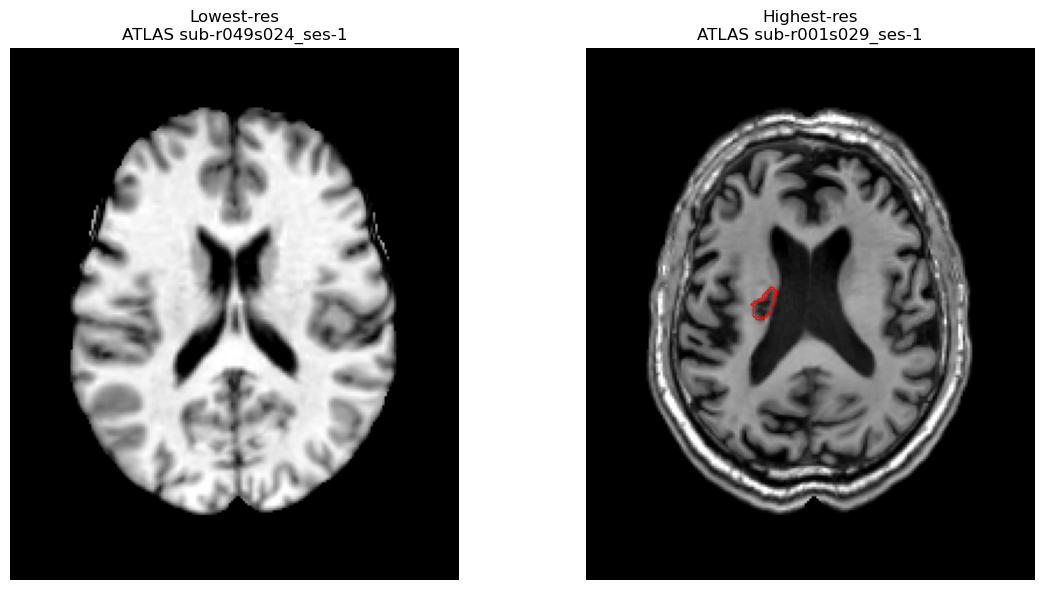

In [36]:
# --- Sanity check: lowest vs highest resolution examples (global split) ---
from pathlib import Path
import numpy as np, pandas as pd, nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, gaussian_filter, laplace
from numpy.fft import rfftn

MANIFEST = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/"
                "mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/"
                "combined_hires_lores_manifest.csv")

df = pd.read_csv(MANIFEST)
assert {"dataset","key","score","t1_path","mask_path"} <= set(df.columns)

# pick min/max score rows (global, across ARC+ATLAS)
df = df.sort_values("score").reset_index(drop=True)
row_lo = df.iloc[0].to_dict()
row_hi = df.iloc[-1].to_dict()

def load_img(path):
    img = nib.load(path)
    vol = img.get_fdata()
    if vol.ndim == 4 and vol.shape[-1] == 1:
        vol = vol[...,0]
    zooms = tuple(float(v) for v in img.header.get_zooms()[:3])
    return vol.astype(np.float32), zooms

def normalize(vol):
    v = vol.copy()
    nz = v[v>0]
    if nz.size:
        p1, p99 = np.percentile(nz, [1,99])
        if p99 > p1:
            v = np.clip((v - p1)/(p99 - p1), 0, 1)
    return v

def mask_edges(m2d):
    m = m2d.astype(bool)
    return binary_dilation(m) & (~m)

# quick sharpness proxies (recompute just for these 2)
def fwhm_blur_mm(vol, vox_mm):
    v = vol.copy()
    nz = v[v>0]
    if nz.size: v = np.clip(v/np.percentile(nz,99), 0, 1)
    sigmas = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
    F = np.abs(rfftn(v))**2; F /= (F.max()+1e-12)
    errs=[]
    for s in sigmas:
        vs = gaussian_filter(v, s)
        Fs = np.abs(rfftn(vs))**2; Fs /= (Fs.max()+1e-12)
        errs.append(np.mean((F-Fs)**2))
    s_best = float(sigmas[int(np.argmin(errs))])
    return 2.355 * s_best * float(np.mean(vox_mm))

def high_freq_energy_frac(vol, cutoff=0.25):
    v = vol.copy()
    nz = v[v>0]
    if nz.size: v = np.clip(v/np.percentile(nz,99), 0, 1)
    V = np.abs(np.fft.fftn(v))**2
    nz_, ny_, nx_ = v.shape
    kz = np.fft.fftfreq(nz_); ky = np.fft.fftfreq(ny_); kx = np.fft.fftfreq(nx_)
    KZ, KY, KX = np.meshgrid(kz, ky, kx, indexing="ij")
    Kr = np.sqrt(KZ**2 + KY**2 + KX**2)
    E = V.sum()
    E_hi = V[Kr >= cutoff*0.5].sum()
    return float(E_hi/(E+1e-12))

def laplacian_variance(vol):
    v = vol.copy()
    nz = v[v>0]
    if nz.size: v = np.clip(v/np.percentile(nz,99), 0, 1)
    L = laplace(v)
    return float(np.var(L[v>0])) if (v>0).any() else float(np.var(L))

def describe(row):
    vol, vox = load_img(row["t1_path"])
    msk, _   = load_img(row["mask_path"])
    z = vol.shape[2]//2
    im2d = normalize(vol[:,:,z])
    m2d  = (msk[:,:,z] > 0.5).astype(np.uint8)
    edges = mask_edges(m2d)
    info = dict(
        dataset=row["dataset"],
        key=row["key"],
        score=float(row["score"]),
        shape=tuple(vol.shape),
        zooms=tuple(vox),
        fwhm_mm=fwhm_blur_mm(vol, vox),
        hf_energy=high_freq_energy_frac(vol),
        lap_var=laplacian_variance(vol),
        t1_path=row["t1_path"],
        mask_path=row["mask_path"],
    )
    return info, im2d, edges

lo_info, lo_im, lo_edges = describe(row_lo)
hi_info, hi_im, hi_edges = describe(row_hi)

print("Lowest-resolution (global score min):")
for k in ["dataset","key","score","shape","zooms","fwhm_mm","hf_energy","lap_var","t1_path","mask_path"]:
    print(f"  {k}: {lo_info[k]}")
print("\nHighest-resolution (global score max):")
for k in ["dataset","key","score","shape","zooms","fwhm_mm","hf_energy","lap_var","t1_path","mask_path"]:
    print(f"  {k}: {hi_info[k]}")

# side-by-side preview
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(lo_im.T, cmap="gray", origin="lower")
axes[0].contour(lo_edges.T, levels=[0.5], linewidths=0.8, colors="r")
axes[0].set_title(f"Lowest-res\n{lo_info['dataset']} {lo_info['key']}")
axes[0].axis("off")
axes[1].imshow(hi_im.T, cmap="gray", origin="lower")
axes[1].contour(hi_edges.T, levels=[0.5], linewidths=0.8, colors="r")
axes[1].set_title(f"Highest-res\n{hi_info['dataset']} {hi_info['key']}")
axes[1].axis("off")
plt.tight_layout()

out_png = MANIFEST.parent / "sanity_min_vs_max_resolution.png"
fig.savefig(out_png, dpi=130, bbox_inches="tight")
print(f"\nSaved snapshot: {out_png}")


In [39]:
# === Global-resolution 70/30 subject-disjoint split (HIRES only) + keep all LORES as separate test ===
import os, re, shutil, random
from pathlib import Path
import pandas as pd

# ---------- Inputs (GLOBAL hires/lores you already built) ----------
COMBO_ROOT = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal")

# Preferred manifest (contains BOTH datasets + bin=hires/lores)
GLOBAL_MANIFEST = COMBO_ROOT / "combined_hires_lores_manifest.csv"

# Materialized folders (from your global 70/30-resolution step)
HIRES_DIR = COMBO_ROOT / "_combined_hires"  # should contain T1+mask (t1/masks OR t1_norm/masks_clean)
LORES_DIR = COMBO_ROOT / "_combined_lores"

# ---------- Helpers ----------
def extract_key(name: str) -> str:
    m_sub = re.search(r"(sub-[^_]+)", name)
    m_ses = re.search(r"(ses-[^_]+)", name)
    parts = []
    if m_sub: parts.append(m_sub.group(1))
    if m_ses: parts.append(m_ses.group(1))
    return "_".join(parts)

def infer_dataset(path: Path) -> str:
    p = str(path)
    if "/ARC/" in p or "ds004884" in p: return "ARC"
    if "/Atlas_2/" in p or "Atlas" in p: return "ATLAS"
    return "UNK"

def index_dir(dir_path: Path, patterns):
    out = {}
    if dir_path.exists():
        for pat in patterns:
            for p in dir_path.rglob(pat):
                out[extract_key(p.name)] = p
    return out

def build_manifest_from_folder(folder: Path) -> pd.DataFrame:
    """
    Build (dataset, key, t1_path, mask_path, bin) from a materialized folder.
    Works with either:
      folder/t1 + folder/masks
      folder/t1_norm + folder/masks_clean
    """
    # prefer t1/masks; fall back to t1_norm/masks_clean
    t1_roots  = [folder / "t1", folder / "t1_norm"]
    msk_roots = [folder / "masks", folder / "masks_clean"]

    t1_map = {}
    for root in t1_roots:
        t1_map.update(index_dir(root, ["*_T1w_MNI_norm.nii.gz","*_T1w_MNI.nii.gz"]))

    msk_map = {}
    for root in msk_roots:
        msk_map.update(index_dir(root, ["*_lesion_mask_MNI_clean.nii.gz","*_lesion_mask_MNI.nii.gz"]))

    keys = sorted(set(t1_map) & set(msk_map))
    rows=[]
    for k in keys:
        t1 = t1_map[k]; m = msk_map[k]
        rows.append(dict(dataset=infer_dataset(t1), key=k, t1_path=str(t1), mask_path=str(m)))
    return pd.DataFrame(rows)

def load_global_manifest() -> pd.DataFrame:
    if GLOBAL_MANIFEST.exists():
        df = pd.read_csv(GLOBAL_MANIFEST)
        # Expect at least: dataset,key,bin,t1_path,mask_path
        need = {"dataset","key","bin","t1_path","mask_path"}
        if need.issubset(df.columns):
            return df.reset_index(drop=True)
        # If present but older format, fall through to rebuild from dirs

    # Rebuild from the materialized dirs and tag the bin from folder
    hi = build_manifest_from_folder(HIRES_DIR); 
    if not hi.empty: hi["bin"] = "hires"
    lo = build_manifest_from_folder(LORES_DIR); 
    if not lo.empty: lo["bin"] = "lores"
    df = pd.concat([hi, lo], ignore_index=True)
    assert not df.empty, "Could not rebuild global manifest from _combined_hires/_combined_lores."
    return df.reset_index(drop=True)

def subject_from_key(k: str) -> str:
    m = re.search(r"(sub-[^_]+)", k)
    return m.group(1) if m else k

def safe_link(src: str | Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def materialize_split(base_dir: Path, df: pd.DataFrame):
    t1d, mkd = base_dir / "t1", base_dir / "masks"
    for _, r in df.iterrows():
        safe_link(r["t1_path"],  t1d / Path(r["t1_path"]).name)
        safe_link(r["mask_path"], mkd / Path(r["mask_path"]).name)

# ---------- Load global hires/lores (combined) ----------
all_df = load_global_manifest()
assert not all_df.empty, "Global hires/lores manifest is empty."

# Sanity: counts should match ~461 hires / 198 lores
print(all_df["bin"].value_counts())

hi_df = all_df[all_df["bin"]=="hires"].copy()
lo_df = all_df[all_df["bin"]=="lores"].copy()
assert len(hi_df) > 0 and len(lo_df) > 0, "Expected both hires and lores to be non-empty."

# ---------- 70/30 SUBJECT-DISJOINT split on HIRES ----------
hi_df["subject"] = hi_df["key"].apply(subject_from_key)
subjects = sorted(hi_df["subject"].unique())
random.Random(42).shuffle(subjects)
n_train = int(round(len(subjects) * 0.70))
sub_train = set(subjects[:n_train])
sub_test  = set(subjects[n_train:])

train_hires = hi_df[hi_df["subject"].isin(sub_train)].copy()
test_hires  = hi_df[hi_df["subject"].isin(sub_test)].copy()

# All lores kept for domain-shift test
test_lores  = lo_df.copy()

# ---------- Save + materialize ----------
OUT_ROOT = COMBO_ROOT / "_combined_splits_70_30_global"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def save_split(name: str, df: pd.DataFrame):
    csvp = OUT_ROOT / f"{name}.csv"
    df.to_csv(csvp, index=False)
    base = OUT_ROOT / name
    materialize_split(base, df)
    return csvp, base

made = {
    "train_hires": save_split("train_hires", train_hires),
    "test_hires":  save_split("test_hires",  test_hires),
    "test_lores":  save_split("test_lores",  test_lores),
}

# ---------- Report ----------
print(f"\nHIRES subjects: {len(subjects)} | train subjects: {len(sub_train)} | test subjects: {len(sub_test)}")
print("Record counts:")
print("  train_hires:", len(train_hires), "| by dataset:", train_hires["dataset"].value_counts().to_dict())
print("  test_hires :", len(test_hires),  "| by dataset:",  test_hires["dataset"].value_counts().to_dict())
print("  test_lores :", len(test_lores),  "| by dataset:",  test_lores["dataset"].value_counts().to_dict())

print("\nSaved:")
for name, (csvp, base) in made.items():
    print(f"  {name}: {csvp}  |  {base}")


bin
hires    461
lores    198
Name: count, dtype: int64

HIRES subjects: 461 | train subjects: 323 | test subjects: 138
Record counts:
  train_hires: 323 | by dataset: {'ATLAS': 198, 'ARC': 125}
  test_hires : 138 | by dataset: {'ATLAS': 86, 'ARC': 52}
  test_lores : 198 | by dataset: {'ATLAS': 178, 'ARC': 20}

Saved:
  train_hires: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/train_hires.csv  |  /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/train_hires
  test_hires: /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/_combined_splits_70_30_global/test_hires.csv  |  /home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manif

In [42]:
from pathlib import Path
import os, shutil, re

SPLIT_ROOT = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/"
                  "mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/"
                  "_combined_splits_70_30_global")

def key(name):
    m_sub = re.search(r"(sub-[^_]+)", name); m_ses = re.search(r"(ses-[^_]+)", name)
    parts=[]; 
    if m_sub: parts.append(m_sub.group(1))
    if m_ses: parts.append(m_ses.group(1))
    return "_".join(parts)

def safe_link(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        if dst.exists() or dst.is_symlink(): dst.unlink()
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)

def flatten_and_check(split_name):
    base = SPLIT_ROOT / split_name
    t1d  = base / "t1"; mkd = base / "masks"
    assert t1d.exists() and mkd.exists(), f"Missing {t1d} or {mkd}"

    # Flatten (link/copy) into split root
    for d in (t1d, mkd):
        for p in d.glob("*.nii.gz"):
            safe_link(p, base / p.name)

    # Sanity: pair by key in the ROOT (single-folder mode)
    nii = list(base.glob("*.nii.gz"))
    t1s = [p for p in nii if ("_T1w_" in p.name)]
    msks= [p for p in nii if ("mask" in p.name)]
    t1_by_key  = {key(p.name): p for p in t1s}
    msk_by_key = {key(p.name): p for p in msks}
    keys = sorted(set(t1_by_key) & set(msk_by_key))
    print(f"{split_name}: files={len(nii)} | T1={len(t1s)} | masks={len(msks)} | pairs={len(keys)}")
    return len(keys)

n_train = flatten_and_check("train_hires")
n_hi    = flatten_and_check("test_hires")
n_lo    = flatten_and_check("test_lores")
print("\nEXPECTED  → train_hires=323, test_hires=138, test_lores=198")
print(f"OBSERVED → train_hires={n_train}, test_hires={n_hi}, test_lores={n_lo}")


train_hires: files=646 | T1=323 | masks=323 | pairs=323
test_hires: files=276 | T1=138 | masks=138 | pairs=138
test_lores: files=396 | T1=198 | masks=198 | pairs=198

EXPECTED  → train_hires=323, test_hires=138, test_lores=198
OBSERVED → train_hires=323, test_hires=138, test_lores=198
